<a href="https://colab.research.google.com/github/sayan-bag2003/Diabetes_Prediction_project/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

Data Collection and Analysis

In [ ]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv("/content/diabetes (1).csv")

In [ ]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(768, 9)

In [ ]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non-Diabetic

1 --> Diabetic

In [ ]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
# separating the data and labels
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [ ]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [57]:
from imblearn.over_sampling import RandomOverSampler
ro = RandomOverSampler()
ro_X , ro_Y = ro.fit_resample(X,Y)


In [58]:
print(ro_Y)

0      1
1      0
2      1
3      0
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Outcome, Length: 1000, dtype: int64


In [59]:
ro_Y.value_counts()

,count
Outcome,
1,500
0,500


In [60]:
scaler = StandardScaler()

In [61]:
scaler.fit(ro_X)
standardized_data = scaler.transform(ro_X)

In [62]:
print(standardized_data)

[[ 0.56529978  0.67903097  0.11952284 ...  0.11482973  0.38861452
   1.35680951]
 [-0.87019992 -1.21308948 -0.18642299 ... -0.7970343  -0.41035459
  -0.28028839]
 [ 1.13949966  1.730209   -0.28840494 ... -1.22691306  0.51888122
  -0.19412535]
 ...
 [-0.87019992  1.39983876 -0.08444105 ...  1.26117309  0.60572569
  -0.53877754]
 [-0.0089001  -0.01174316  0.01754089 ... -0.49742183  1.88523419
   0.92599428]
 [ 1.71369954 -0.43221437  0.01754089 ... -0.67979464 -1.01826586
   0.49517904]]


In [63]:
ro_X = standardized_data
# ro_Y should already be balanced from the RandomOverSampler step, no need to reassign it here
# ro_Y = diabetes_dataset['Outcome'] # This line was incorrect
print(ro_X)
print(ro_Y)

[[ 0.56529978  0.67903097  0.11952284 ...  0.11482973  0.38861452
   1.35680951]
 [-0.87019992 -1.21308948 -0.18642299 ... -0.7970343  -0.41035459
  -0.28028839]
 [ 1.13949966  1.730209   -0.28840494 ... -1.22691306  0.51888122
  -0.19412535]
 ...
 [-0.87019992  1.39983876 -0.08444105 ...  1.26117309  0.60572569
  -0.53877754]
 [-0.0089001  -0.01174316  0.01754089 ... -0.49742183  1.88523419
   0.92599428]
 [ 1.71369954 -0.43221437  0.01754089 ... -0.67979464 -1.01826586
   0.49517904]]
0      1
1      0
2      1
3      0
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Outcome, Length: 1000, dtype: int64


Train Test Split

In [64]:
ro_X_train, ro_X_test, ro_Y_train, ro_Y_test = train_test_split(ro_X,ro_Y, test_size = 0.2, stratify=ro_Y, random_state=42)

In [65]:
print(ro_X.shape, ro_X_train.shape, ro_X_test.shape)

(1000, 8) (800, 8) (200, 8)


Training the Model

In [66]:
classifier = svm.SVC(kernel='linear')

In [67]:
#training the support vector Machine Classifier
classifier.fit(ro_X_train, ro_Y_train)

SVC(kernel='linear')

Accuracy Score

In [68]:
# accuracy score on the training data
ro_X_train_prediction = classifier.predict(ro_X_train)
training_data_accuracy = accuracy_score(ro_X_train_prediction, ro_Y_train)

In [69]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.7575


In [76]:
# accuracy score on the test data
ro_X_test_prediction = classifier.predict(ro_X_test)
test_data_accuracy = accuracy_score(ro_X_test_prediction, ro_Y_test)

In [77]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.745


Confusion Matrix and Classification Report

Confusion Matrix:
[[76 24]
 [27 73]]


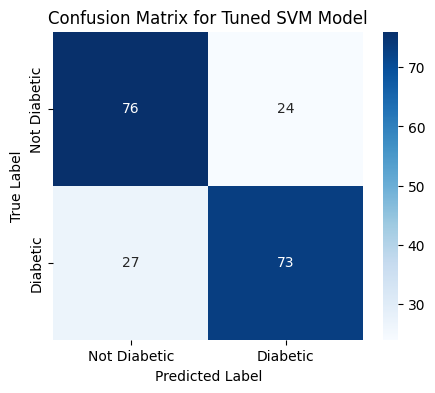

In [78]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate Confusion Matrix
conf_matrix = confusion_matrix(ro_Y_test, ro_X_test_prediction)

print("Confusion Matrix:")
print(conf_matrix)

# Plotting the Confusion Matrix as a Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic', 'Diabetic'],
            yticklabels=['Not Diabetic', 'Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned SVM Model')
plt.show()

In [82]:
# Generate Classification Report
class_report = classification_report(ro_Y_test, ro_X_test_prediction)

print("Classification Report:")
print(class_report)

# Re-print accuracy for easy comparison
print('Accuracy score of the tuned test data : ', test_data_accuracy)

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       100
           1       0.75      0.73      0.74       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200

Accuracy score of the tuned test data :  0.745


Making a Predictive System

In [83]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[  4.78049252 159.16341993  70.98759098  18.73094846 165.2233521
   26.38582035   0.50220571  51.55730457]]
[1]
The person is diabetic
